# Black-hat Morphology

本 notebook 紀錄 **black-hat morphology** 的核心概念、實作流程、參數影響與使用限制。

這份內容使用 MVTec AD `tile / crack` 影像作為範例。重點不是建立完整瑕疵檢測系統，而是理解 black-hat 在影像處理中的角色：

> black-hat 不是找「絕對很黑」的 pixel，而是強化「相對於周圍背景更暗」的局部結構。

這個特性使它適合用在暗色裂縫、暗色刮痕、細小暗縫等情境。

In [4]:
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt

# 控制 notebook 顯示圖片大小，避免輸出過大
plt.rcParams["figure.dpi"] = 100
plt.rcParams["savefig.dpi"] = 100
plt.rcParams["font.size"] = 10

## 1. Data Path Setup

本 notebook 預期使用以下資料結構：

```text
data/
├── good/
├── defect/
│   └── crack/
└── ground_truth/
    └── crack/
```

若 notebook 放置位置不同，可以直接修改 `DATA_DIR`。

In [5]:
DATA_DIR_CANDIDATES = [
    Path("data"),
    Path("../data"),
    Path("../../data"),
    Path("../../../data"),
]

DATA_DIR = None

for candidate in DATA_DIR_CANDIDATES:
    if (candidate / "defect" / "crack").exists():
        DATA_DIR = candidate
        break

if DATA_DIR is None:
    raise FileNotFoundError(
        "Cannot find data directory. Please set DATA_DIR manually, "
        "for example: DATA_DIR = Path('../data')"
    )

GOOD_DIR = DATA_DIR / "good"
CRACK_DIR = DATA_DIR / "defect" / "crack"
CRACK_GT_DIR = DATA_DIR / "ground_truth" / "crack"

print("DATA_DIR:", DATA_DIR.resolve())
print("CRACK_DIR:", CRACK_DIR)
print("CRACK_GT_DIR:", CRACK_GT_DIR)

DATA_DIR: E:\Knowledge_Base\Knowledge Base\Computer Vision\01_image_processing\useful_methods\black_hat_morphology\data
CRACK_DIR: data\defect\crack
CRACK_GT_DIR: data\ground_truth\crack


## 2. Utility Functions

共用函式集中在此處，後續每個實驗只保留與 black-hat 直接相關的操作。

In [6]:
def read_bgr_image(image_path: Path) -> np.ndarray:
    image = cv2.imread(str(image_path), cv2.IMREAD_COLOR)
    if image is None:
        raise FileNotFoundError(f"Image not found or cannot be read: {image_path}")
    return image


def read_gray_image(image_path: Path) -> np.ndarray:
    image = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
    if image is None:
        raise FileNotFoundError(f"Image not found or cannot be read: {image_path}")
    return image


def get_gt_path(image_path: Path) -> Path:
    return CRACK_GT_DIR / f"{image_path.stem}_mask.png"


def show_image_grid(images, titles, ncols=4, figsize=(12, 6), cmap_list=None, suptitle=None):
    n = len(images)
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = np.array(axes).reshape(-1)

    if cmap_list is None:
        cmap_list = [None] * n

    for idx, ax in enumerate(axes):
        if idx < n:
            ax.imshow(images[idx], cmap=cmap_list[idx])
            ax.set_title(titles[idx], fontsize=9)
        ax.axis("off")

    if suptitle is not None:
        fig.suptitle(suptitle, fontsize=12)

    plt.tight_layout()
    plt.show()


def remove_small_components(binary_mask: np.ndarray, min_area: int = 40) -> np.ndarray:
    binary = (binary_mask > 0).astype(np.uint8)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary, connectivity=8)

    cleaned = np.zeros_like(binary, dtype=np.uint8)

    for label_id in range(1, num_labels):
        area = stats[label_id, cv2.CC_STAT_AREA]
        if area >= min_area:
            cleaned[labels == label_id] = 255

    return cleaned


def overlay_mask_on_image(image_rgb: np.ndarray, mask: np.ndarray, alpha: float = 0.45) -> np.ndarray:
    overlay = image_rgb.copy()

    if mask is None:
        return overlay

    mask = np.asarray(mask)

    if mask.shape[:2] != image_rgb.shape[:2]:
        mask = cv2.resize(
            mask,
            (image_rgb.shape[1], image_rgb.shape[0]),
            interpolation=cv2.INTER_NEAREST
        )

    mask_bool = mask > 0
    if not np.any(mask_bool):
        return overlay

    red_layer = np.zeros_like(image_rgb, dtype=np.uint8)
    red_layer[:, :, 0] = 255

    overlay[mask_bool] = (
        image_rgb[mask_bool].astype(np.float32) * (1 - alpha)
        + red_layer[mask_bool].astype(np.float32) * alpha
    ).astype(np.uint8)

    return overlay

## 3. Load a Crack Example

先使用一張 crack 影像觀察 black-hat 的基本效果。若 `000.png` 存在，預設使用它；否則自動取第一張 crack image。

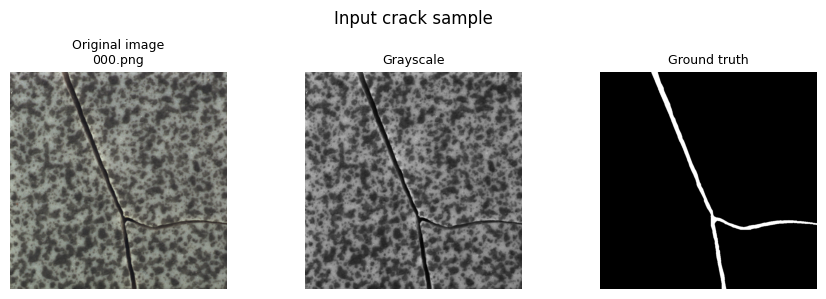

In [7]:
crack_image_paths = sorted(CRACK_DIR.glob("*.png"))

if len(crack_image_paths) == 0:
    raise FileNotFoundError(f"No crack images found in: {CRACK_DIR}")

preferred_path = CRACK_DIR / "000.png"
image_path = preferred_path if preferred_path.exists() else crack_image_paths[0]
gt_path = get_gt_path(image_path)

image_bgr = read_bgr_image(image_path)
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)

gt_mask = read_gray_image(gt_path) if gt_path.exists() else None

images = [image_rgb, gray]
titles = [f"Original image\n{image_path.name}", "Grayscale"]
cmaps = [None, "gray"]

if gt_mask is not None:
    images.append(gt_mask)
    titles.append("Ground truth")
    cmaps.append("gray")

show_image_grid(
    images=images,
    titles=titles,
    ncols=3,
    figsize=(9, 3),
    cmap_list=cmaps,
    suptitle="Input crack sample"
)

### Observation

此類 crack 通常是嵌在磁磚紋理中的暗色細長結構。固定 threshold 只能找「絕對暗」的區域，但 black-hat 更關心「該位置是否比周圍背景更暗」。

## 4. Review: Morphological Closing

Black-hat 的前置概念是 **closing**。

```text
closing = dilation followed by erosion
```

在灰階影像中，可以把 closing 直覺理解成：

> 用鄰近背景去補平小型暗洞、暗縫或暗線。

因此，如果 crack 是比周圍更暗的細小結構，closing 會傾向把它補起來，得到一張比較接近「沒有暗裂縫」的背景估計圖。

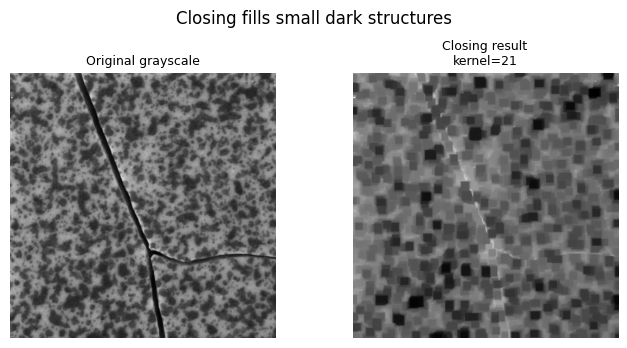

In [8]:
kernel_size = 21
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (kernel_size, kernel_size))

closing = cv2.morphologyEx(gray, cv2.MORPH_CLOSE, kernel)

show_image_grid(
    images=[gray, closing],
    titles=["Original grayscale", f"Closing result\nkernel={kernel_size}"],
    ncols=2,
    figsize=(7, 3.5),
    cmap_list=["gray", "gray"],
    suptitle="Closing fills small dark structures"
)

### Observation

Closing 後的影像不是最終結果，而是用來估計「如果那些局部暗縫被周圍背景補平，影像會長什麼樣」。Black-hat 接下來就是利用這張補平後的影像與原圖之間的差異。

## 5. Black-hat Definition and Mechanism

Black-hat 的定義是：

```text
black-hat = closing image - original image
```

它的內部邏輯可以這樣理解：

1. closing 先把小暗縫、小暗洞補起來。
2. 補起來後的影像減掉原圖。
3. 被補起來的暗色結構會留下較大的差值。
4. 一般背景因為 closing 前後差異小，response 也較弱。

因此 black-hat 輸出的不是 segmentation mask，而是一張 **dark local structure response map**。

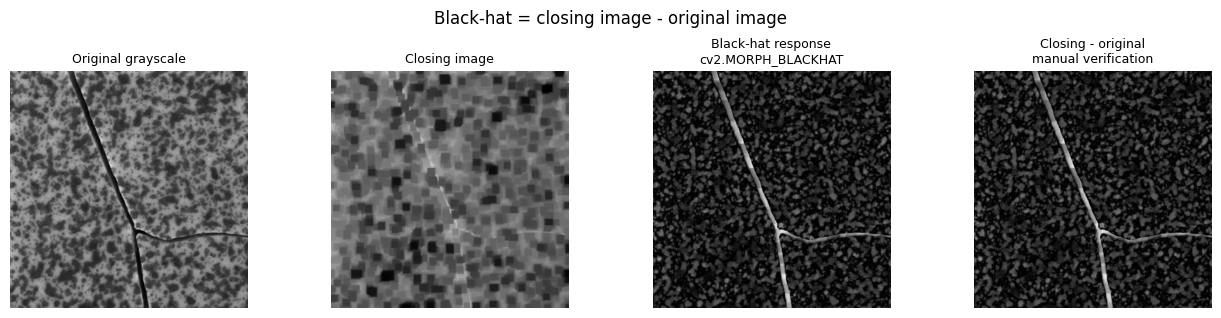

In [9]:
blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
blackhat_norm = cv2.normalize(blackhat, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

manual_blackhat = cv2.subtract(closing, gray)
manual_blackhat_norm = cv2.normalize(manual_blackhat, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

show_image_grid(
    images=[gray, closing, blackhat_norm, manual_blackhat_norm],
    titles=[
        "Original grayscale",
        "Closing image",
        "Black-hat response\ncv2.MORPH_BLACKHAT",
        "Closing - original\nmanual verification"
    ],
    ncols=4,
    figsize=(13, 3.2),
    cmap_list=["gray"] * 4,
    suptitle="Black-hat = closing image - original image"
)

### Observation

Black-hat response 亮的地方，代表該區域在 closing 後被明顯補亮，也就是原圖中存在比周圍更暗的局部結構。這正是暗色 crack 能被凸顯的原因。

這裡的重點是：black-hat 不是直接判斷 pixel 灰階值是否小於某個固定數字，而是在比較原圖與局部背景估計之間的差異。

## 6. Kernel Size Experiment

Black-hat 的效果高度依賴 structuring element 的大小。

- kernel 太小：補不掉目標暗結構，response 可能不完整。
- kernel 適中：能補平暗裂縫，response 較清楚。
- kernel 太大：可能把較大尺度的背景變化也放大。

kernel 的選擇應該和「想強化的結構尺度」有關，而不是越大越好。

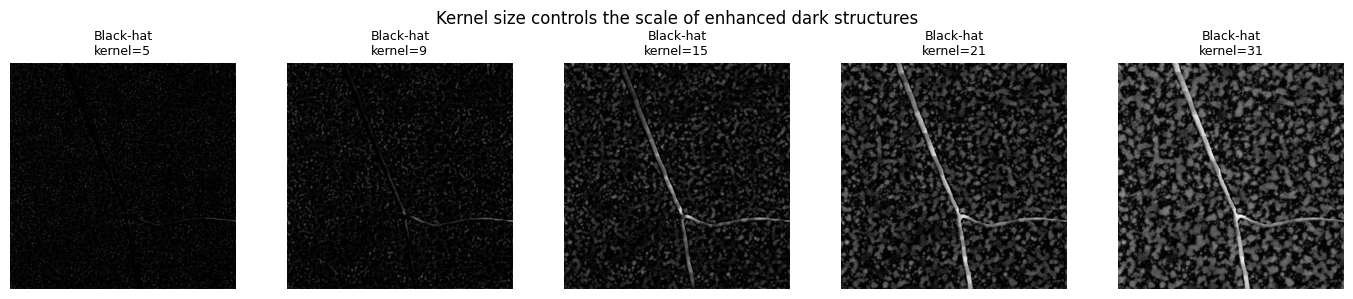

In [10]:
kernel_sizes = [5, 9, 15, 21, 31]
blackhat_by_kernel = {}

for k in kernel_sizes:
    kobj = cv2.getStructuringElement(cv2.MORPH_RECT, (k, k))
    bh = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kobj)
    bh_norm = cv2.normalize(bh, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    blackhat_by_kernel[k] = bh_norm

show_image_grid(
    images=[blackhat_by_kernel[k] for k in kernel_sizes],
    titles=[f"Black-hat\nkernel={k}" for k in kernel_sizes],
    ncols=5,
    figsize=(14, 3),
    cmap_list=["gray"] * len(kernel_sizes),
    suptitle="Kernel size controls the scale of enhanced dark structures"
)

### Observation

小 kernel 只會反應局部細碎變化；較大的 kernel 能強化較長的暗色結構，但也可能放大背景不均勻。實務上通常需要比較數個 kernel size，再依照目標結構與背景紋理選擇折衷值。

## 7. Black-hat vs Manual Threshold

Manual threshold 問的是：

```text
這個 pixel 是否低於某個固定灰階值？
```

Black-hat 問的是：

```text
這個位置是否比附近背景更暗？
```

這是兩者最重要的差異。對於背景紋理複雜的 tile 影像，單純固定 threshold 很容易同時抓到正常暗斑；black-hat 則先把局部暗色結構轉成 response map，再從 response 中取出較強的候選區域。

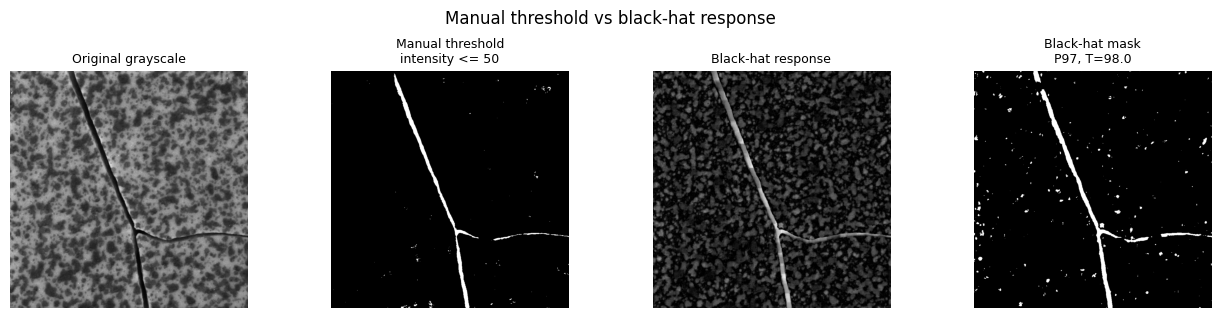

In [11]:
manual_threshold_value = 50
_, manual_mask = cv2.threshold(gray, manual_threshold_value, 255, cv2.THRESH_BINARY_INV)

selected_kernel_size = 21
selected_percentile = 97

kobj = cv2.getStructuringElement(cv2.MORPH_RECT, (selected_kernel_size, selected_kernel_size))
blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kobj)
blackhat_norm = cv2.normalize(blackhat, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

threshold_value = np.percentile(blackhat_norm, selected_percentile)
blackhat_mask = (blackhat_norm >= threshold_value).astype(np.uint8) * 255

show_image_grid(
    images=[gray, manual_mask, blackhat_norm, blackhat_mask],
    titles=[
        "Original grayscale",
        f"Manual threshold\nintensity <= {manual_threshold_value}",
        "Black-hat response",
        f"Black-hat mask\nP{selected_percentile}, T={threshold_value:.1f}"
    ],
    ncols=4,
    figsize=(13, 3.2),
    cmap_list=["gray"] * 4,
    suptitle="Manual threshold vs black-hat response"
)

### Observation

Manual threshold 的結果直接受原圖灰階值影響；black-hat 則先把局部暗色結構轉成 response，再進行 thresholding。這使 black-hat 較適合處理「不是絕對很黑，但相對周圍更暗」的裂縫。

## 8. From Response Map to Candidate Mask

Black-hat 本身只產生 response map，不是 final mask。若要用於 detection 或 localization，通常還需要：

1. response thresholding
2. morphology connection
3. small component removal
4. optional shape filtering

本節只示範從 black-hat response 轉成 candidate mask 的基本流程。

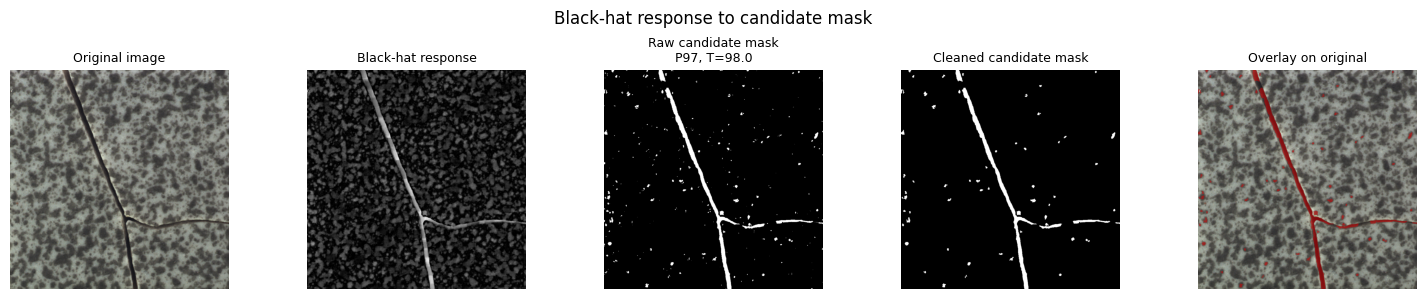

In [12]:
def blackhat_candidate_pipeline(gray_image, kernel_size=21, percentile=97, min_area=40):
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (kernel_size, kernel_size))

    response = cv2.morphologyEx(gray_image, cv2.MORPH_BLACKHAT, kernel)
    response_norm = cv2.normalize(response, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    t = np.percentile(response_norm, percentile)
    raw_mask = (response_norm >= t).astype(np.uint8) * 255

    close_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    closed = cv2.morphologyEx(raw_mask, cv2.MORPH_CLOSE, close_kernel, iterations=1)
    cleaned = remove_small_components(closed, min_area=min_area)

    return response_norm, raw_mask, cleaned, t


response, raw_mask, cleaned_mask, t = blackhat_candidate_pipeline(
    gray,
    kernel_size=21,
    percentile=97,
    min_area=40
)

overlay = overlay_mask_on_image(image_rgb, cleaned_mask)

show_image_grid(
    images=[image_rgb, response, raw_mask, cleaned_mask, overlay],
    titles=[
        "Original image",
        "Black-hat response",
        f"Raw candidate mask\nP97, T={t:.1f}",
        "Cleaned candidate mask",
        "Overlay on original"
    ],
    ncols=5,
    figsize=(15, 3),
    cmap_list=[None, "gray", "gray", "gray", None],
    suptitle="Black-hat response to candidate mask"
)

### Observation

Cleaned candidate mask 可以作為 localization 的初步結果，但它仍然不是完整 segmentation。若要進一步做 image-level 判斷，還需要 connected component 或其他形狀規則。Black-hat 的角色是「強化與生成候選區域」，不是單獨完成整個偵測任務。

## 9. Limitation Example: Non-dark Crack

Black-hat 的主要假設是：目標結構比周圍背景更暗。若某個 crack 並不呈現暗色，或與背景的局部暗色對比不足，black-hat response 可能很弱。

若資料集中存在 `005.png`，本節將用它作為限制案例。

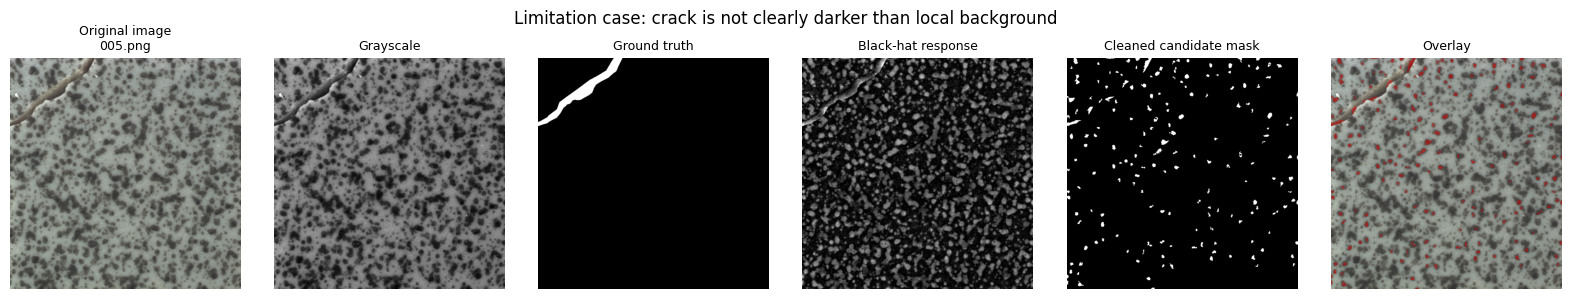

In [13]:
limitation_path = CRACK_DIR / "005.png"

if limitation_path.exists():
    limitation_bgr = read_bgr_image(limitation_path)
    limitation_rgb = cv2.cvtColor(limitation_bgr, cv2.COLOR_BGR2RGB)
    limitation_gray = cv2.cvtColor(limitation_bgr, cv2.COLOR_BGR2GRAY)
    limitation_gt_path = get_gt_path(limitation_path)
    limitation_gt = read_gray_image(limitation_gt_path) if limitation_gt_path.exists() else None

    limitation_response, limitation_raw, limitation_cleaned, limitation_t = blackhat_candidate_pipeline(
        limitation_gray,
        kernel_size=21,
        percentile=97,
        min_area=40
    )

    limitation_overlay = overlay_mask_on_image(limitation_rgb, limitation_cleaned)

    images = [limitation_rgb, limitation_gray, limitation_response, limitation_cleaned, limitation_overlay]
    titles = [
        "Original image\n005.png",
        "Grayscale",
        "Black-hat response",
        "Cleaned candidate mask",
        "Overlay"
    ]
    cmaps = [None, "gray", "gray", "gray", None]

    if limitation_gt is not None:
        images.insert(2, limitation_gt)
        titles.insert(2, "Ground truth")
        cmaps.insert(2, "gray")

    show_image_grid(
        images=images,
        titles=titles,
        ncols=6,
        figsize=(16, 3),
        cmap_list=cmaps,
        suptitle="Limitation case: crack is not clearly darker than local background"
    )
else:
    print("005.png was not found. Skip limitation example.")

### Observation

如果裂縫不是明顯暗色結構，black-hat 不一定能產生足夠強的 response。這不是單純調參問題，而是方法假設與樣本特性不一致。

因此 black-hat 適合 dark crack，但不應被視為所有裂縫型態的通用解法。

## 10. Engineering Notes

Black-hat morphology 的實務判斷可以整理如下：

1. **適合情境**  
   目標是比周圍背景更暗的小型或細長結構，例如 dark crack、dark scratch、small dark gap。

2. **不是 final detector**  
   Black-hat 輸出的是 response map。若要做 detection 或 localization，仍需要 thresholding、morphology cleanup 與 component filtering。

3. **kernel size 是關鍵參數**  
   kernel 應該大於目標暗結構的寬度，但不能大到過度放大背景不均勻。

4. **比固定 threshold 更有彈性**  
   固定 threshold 看絕對灰階值；black-hat 看局部相對差異，因此較能處理不同整體亮度下的暗色裂縫。

5. **限制要明確標示**  
   若目標不是暗色，或背景本身有大量暗色線狀紋理，black-hat 仍可能失效或產生 false positives。

本方法的核心價值不是「把裂縫全部找出來」，而是提供一個可解釋的 dark-structure enhancement step，讓後續規則或模型更容易取得有意義的候選區域。

## Reference

- OpenCV Morphological Transformations: `cv.morphologyEx()` supports operations such as opening, closing, top-hat and black-hat.
- Black-hat is commonly defined as the difference between the closing of the input image and the input image.

此 notebook 的實作以 `cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)` 為主。